In [ ]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


import import_ipynb
import nbimporter
from utils import prepareTrainingSet30Sec, standardization, prepareTrainingSet3Sec, metrics,encode_labels,Grafico_Tre_Valori, ConfrontoGrafico_30_e_3 # type: ignore



In [2]:
X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()

In [3]:

knn = KNeighborsClassifier(n_neighbors=11)
 
# Addestriamo il modello
knn.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = knn.predict(X_test)

metrics(y_test, y_pred)
before_30sec=accuracy_score(y_test, y_pred)

Accuratezza: 0.2550
Precision: 0.2356
Recall: 0.2667
F1-score: 0.2416
F2-score: 0.2542


c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\romeo\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


In [4]:
X_train, X_test= standardization(X_train, X_test)

knn = KNeighborsClassifier(n_neighbors=11)
 
# Addestriamo il modello
knn.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = knn.predict(X_test)

before_30sec_standadization=accuracy_score(y_test, y_pred)

metrics(y_test, y_pred)


Accuratezza: 0.6600
Precision: 0.6767
Recall: 0.6707
F1-score: 0.6675
F2-score: 0.6681


In [ ]:
X_train, X_test, y_train, y_test= prepareTrainingSet30Sec()

y_train, y_test, label_encoder = encode_labels(y_train, y_test)

X_train, X_test= standardization(X_train, X_test)


# Configurazione del modello KNN
knn = KNeighborsClassifier()

# Griglia degli iperparametri
param_grid = {
    'n_neighbors': [3, 5, 7],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}


# Grid Search su tutte le metriche
grid_search = GridSearchCV( estimator=knn, param_grid=param_grid, scoring='accuracy', refit='accuracy',  cv=5)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)


#Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
after_30sec=accuracy_score(y_test, y_pred)
metrics(y_test, y_pred)
knn30Sec= after_30sec


Migliori iperparametri trovati: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Accuratezza: 0.7100
Precision: 0.7264
Recall: 0.7182
F1-score: 0.7179
F2-score: 0.7169


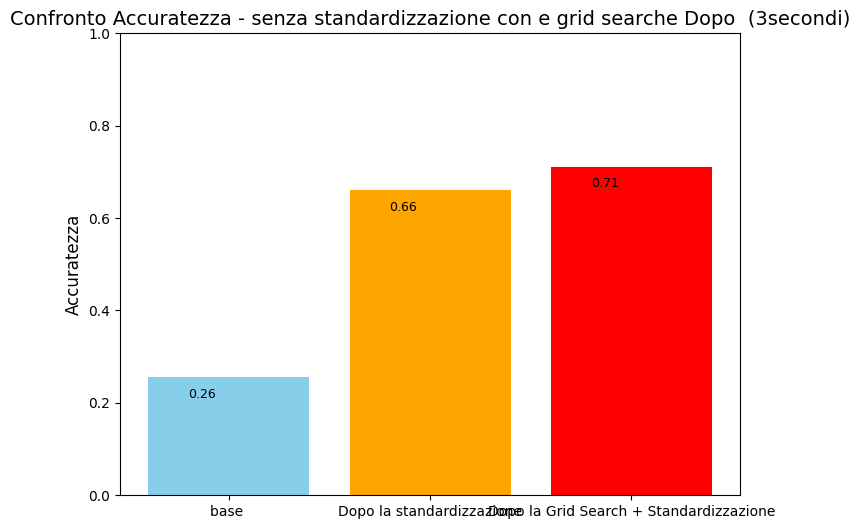

In [6]:
Grafico_Tre_Valori(before_30sec,before_30sec_standadization,after_30sec)

3 secondi


In [7]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()


In [8]:
# Addestriamo il modello
knn.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = knn.predict(X_test)

before_3sec=accuracy_score(y_test, y_pred)

metrics(y_test, y_pred)

Accuratezza: 0.2708
Precision: 0.2657
Recall: 0.2710
F1-score: 0.2656
F2-score: 0.2682


In [9]:
X_train, X_test= standardization(X_train, X_test)

# Addestriamo il modello
knn.fit(X_train, y_train)

# Prediciamo sul set di test
y_pred = knn.predict(X_test)

before_3sec_standadization=accuracy_score(y_test, y_pred)
metrics(y_test, y_pred)

Accuratezza: 0.9019
Precision: 0.9024
Recall: 0.9010
F1-score: 0.9010
F2-score: 0.9008


In [13]:

X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()

y_train, y_test, label_encoder = encode_labels(y_train, y_test)

X_train, X_test= standardization(X_train, X_test)


# Configurazione del modello KNN
knn = KNeighborsClassifier()

# Griglia degli iperparametri
param_grid = {
    'n_neighbors': [3, 5, 7],
    'metric': ['euclidean', 'manhattan'],
    'weights': ['uniform', 'distance']
}


# Grid Search su tutte le metriche
grid_search = GridSearchCV( estimator=knn, param_grid=param_grid, scoring='accuracy', refit='accuracy',  cv=5)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)


#Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# Calcolo delle metriche
metrics(y_test, y_pred)
after_3sec=accuracy_score(y_test, y_pred)
knn3Sec=after_3sec


Migliori iperparametri trovati: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
Accuratezza: 0.9374
Precision: 0.9372
Recall: 0.9370
F1-score: 0.9369
F2-score: 0.9369


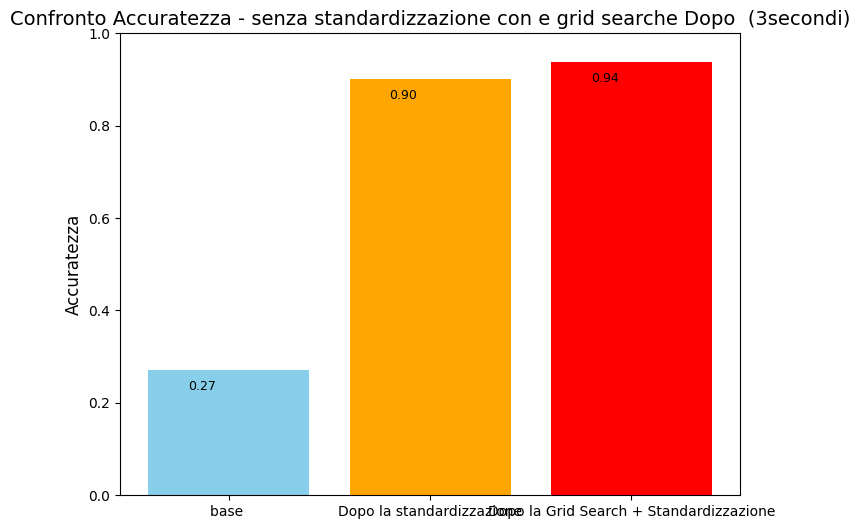

In [14]:
Grafico_Tre_Valori(before_3sec,before_3sec_standadization,after_3sec)

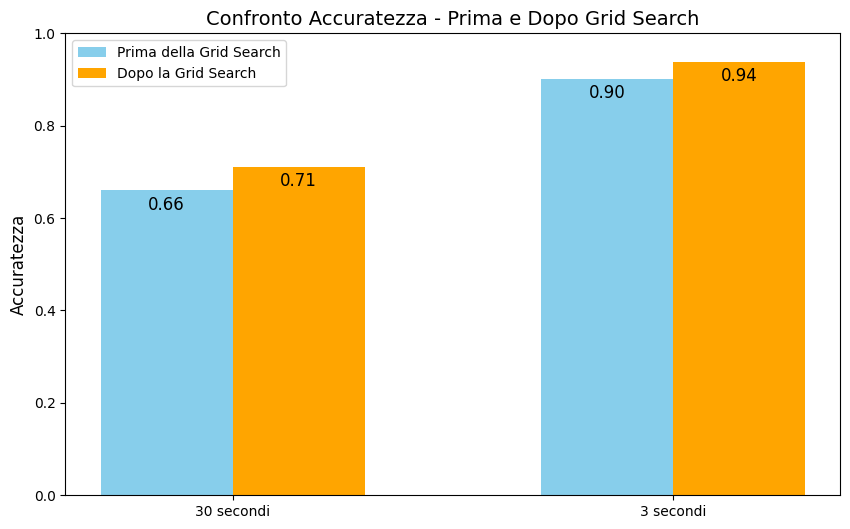

In [12]:
ConfrontoGrafico_30_e_3(before_30sec_standadization,before_3sec_standadization,after_30sec,after_3sec)